<a href="https://colab.research.google.com/github/zsaaupo/HeartDiseaseDetection/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
# load the dataset from drive
drive.mount('/content/drive')
dataset = '/content/drive/My Drive/Colab Notebooks/Dataset/heart.csv'

df = pd.read_csv(dataset)

# Display the first 5 rows of the DataFrame
print(df.head())

Mounted at /content/drive
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [ ]:
print("\nMissing value:",df.isnull().sum())
print("\nData Summary:", df.describe())


Missing value: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data Summary:                age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000

In [ ]:
df = df.rename(columns={
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'Chest_Pain_Type',
    'trestbps': 'Resting_Blood_Pressure',
    'chol': 'Cholesterol',
    'fbs': 'Fasting_Blood_Sugar',
    'restecg': 'Resting_ECG',
    'thalach': 'Max_Heart_Rate',
    'exang': 'Exercise_Induced_Angina',
    'oldpeak': 'ST_Depression',
    'slope': 'ST_Slope',
    'ca': 'Major_Vessels',
    'thal': 'Thalassemia',
    'target': 'Heart_Disease'
})

print("Columns renamed successfully!")
print(df.head())

Columns renamed successfully!
   Age  Sex  Chest_Pain_Type  Resting_Blood_Pressure  Cholesterol  \
0   52    1                0                     125          212   
1   53    1                0                     140          203   
2   70    1                0                     145          174   
3   61    1                0                     148          203   
4   62    0                0                     138          294   

   Fasting_Blood_Sugar  Resting_ECG  Max_Heart_Rate  Exercise_Induced_Angina  \
0                    0            1             168                        0   
1                    1            0             155                        1   
2                    0            1             125                        1   
3                    0            1             161                        0   
4                    1            1             106                        0   

   ST_Depression  ST_Slope  Major_Vessels  Thalassemia  Heart_Disease  
0 

In [ ]:
# Define the list of important features
selected_features = [
    'Thalassemia',
    'Chest_Pain_Type',
    'Major_Vessels',
    'ST_Depression',
    'Exercise_Induced_Angina',
    'Max_Heart_Rate',
    'ST_Slope',
    'Age',
    'Sex',
    'Resting_ECG'
]

# Separate features and target using only the important features
# X = df.drop(columns=["Heart_Disease"])
X = df[selected_features]
y = df['Heart_Disease']

# Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize all features
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verification
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

print("\nVerification of Scaled Data (First 5 rows of X_train_scaled):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Training set shape: (820, 10)
Testing set shape:  (205, 10)

Verification of Scaled Data (First 5 rows of X_train_scaled):
   Thalassemia  Chest_Pain_Type  Major_Vessels  ST_Depression  \
0    -0.545193         1.008275       2.171691      -0.210661   
1    -0.545193        -0.916720      -0.725467      -0.912152   
2    -0.545193         1.008275      -0.725467      -0.912152   
3     1.110579        -0.916720      -0.725467      -0.473720   
4    -0.545193         1.008275      -0.725467       1.192321   

   Exercise_Induced_Angina  Max_Heart_Rate  ST_Slope       Age       Sex  \
0                -0.725949       -1.019094  1.005264 -0.585840  0.654654   
1                 1.377507        0.202882  1.005264  1.051477 -1.527525   
2                -0.725949        0.770228  1.005264 -0.040068 -1.527525   
3                -0.725949        0.508376 -0.640079  0.505705  0.654654   
4                -0.725949        0.726586 -0.640079 -0.367531  0.654654   

   Resting_ECG  
0    -0.9837

### What is Logistic Regression?

Logistic Regression is a statistical model used for binary classification tasks. Despite its name, it's a classification algorithm, not a regression algorithm in the traditional sense.

### The Core Idea
Logistic Regression models the probability that a given input belongs to a particular class (e.g., probability of having heart disease). It uses a *sigmoid function* (also called the logistic function) to map any real-valued number into a probability between 0 and 1.

### Mathematical Equation

1.  **Linear Combination of Inputs:** First, Logistic Regression calculates a linear combination of the input features, similar to Linear Regression:
    `z = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ`
    Where:
    *   `z` is the weighted sum of inputs.
    *   `b₀` is the bias (intercept).
    *   `b₁, b₂, ..., bₙ` are the coefficients (weights) for each feature.
    *   `x₁, x₂, ..., xₙ` are the input features.

2.  **Sigmoid Function:** The value `z` is then passed through the sigmoid function, which squashes the output to a value between 0 and 1:
    `P(y=1|x) = σ(z) = 1 / (1 + e⁻ᶻ)`
    Where:
    *   `P(y=1|x)` is the probability that the output `y` is 1 (the positive class) given the input features `x`.
    *   `σ` (sigma) denotes the sigmoid function.
    *   `e` is Euler's number (the base of the natural logarithm).

### Interpretation
The output `P(y=1|x)` can be interpreted as the probability of the positive class. A threshold (commonly 0.5) is then applied to classify the input. If `P(y=1|x) ≥ 0.5`, the input is classified as 1; otherwise, it's classified as 0.

### Why the Sigmoid Function?
*   It produces a smooth, S-shaped curve, which is ideal for modeling probabilities that should gradually change from 0 to 1.
*   It's differentiable, which is crucial for optimization algorithms (like gradient descent) used to find the best coefficients (`b` values).

In essence, Logistic Regression finds the best-fitting sigmoid curve to separate the data points into different classes, based on the input features.

### Implementing Logistic Regression

Now, let's train a Logistic Regression model, which is specifically designed for binary classification tasks, on the same selected and scaled features. We'll evaluate its performance using appropriate classification metrics.

In [ ]:
# Initialize and train the Logistic Regression model
logistic_reg_model = LogisticRegression(random_state=42)
logistic_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model with selected features trained successfully!")

Logistic Regression model with selected features trained successfully!


In [ ]:
# Make predictions on the scaled test data
y_pred_lr = logistic_reg_model.predict(X_test_scaled)
y_pred_proba_lr = logistic_reg_model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class (1)

# Evaluate the Logistic Regression model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
class_report_lr = classification_report(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\nAccuracy for Logistic Regression: {accuracy_lr:.6f}")
print(f"\nConfusion Matrix:\n{conf_matrix_lr}")
print(f"\nClassification Report:\n{class_report_lr}")
print(f"\nROC AUC Score: {roc_auc_lr:.4f}")


Accuracy for Logistic Regression: 0.824390

Confusion Matrix:
[[76 26]
 [10 93]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       102
           1       0.78      0.90      0.84       103

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205


ROC AUC Score: 0.8841


### Visualizing Confusion Matrix

Let's visualize the confusion matrix to see the counts of true positives, true negatives, false positives, and false negatives.

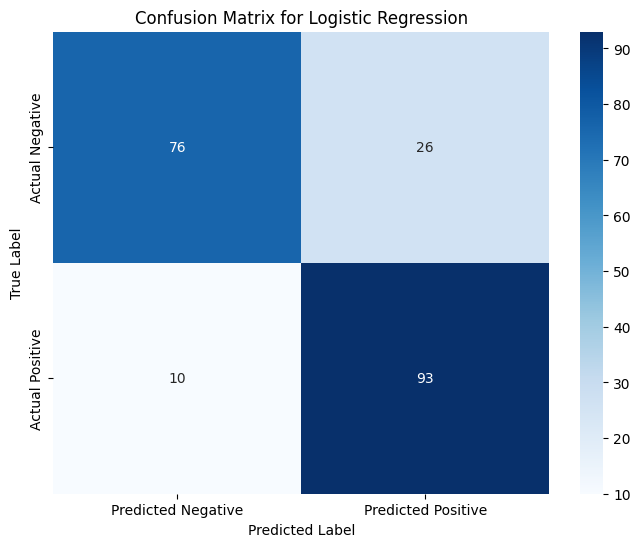

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### Visualizing Logistic Regression Performance

Let's visualize the ROC curve for the Logistic Regression model. The Receiver Operating Characteristic (ROC) curve is a useful plot to illustrate the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) is a common metric to summarize the ROC curve's performance.

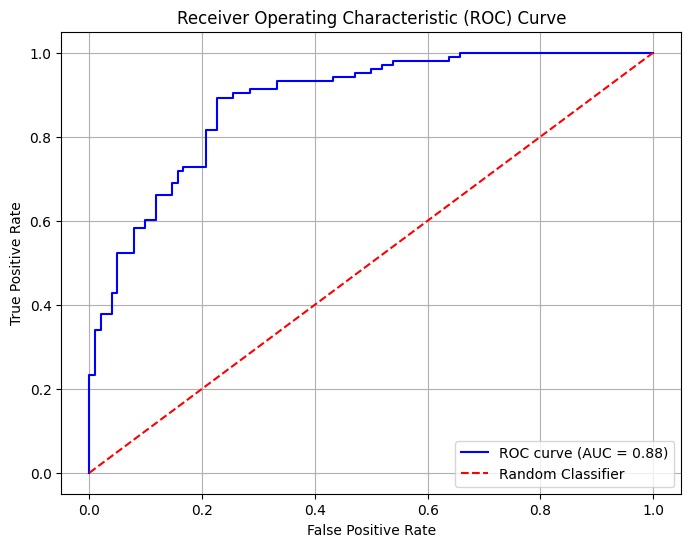

In [ ]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Coefficient Plot for Logistic Regression

For Logistic Regression, the coefficients represent the change in the log-odds of the target variable for a one-unit change in the predictor variable, holding other predictors constant. A larger absolute value of a coefficient indicates a stronger impact on the probability of the outcome.

/tmp/ipykernel_6904/2932166354.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df_sorted, palette='viridis')


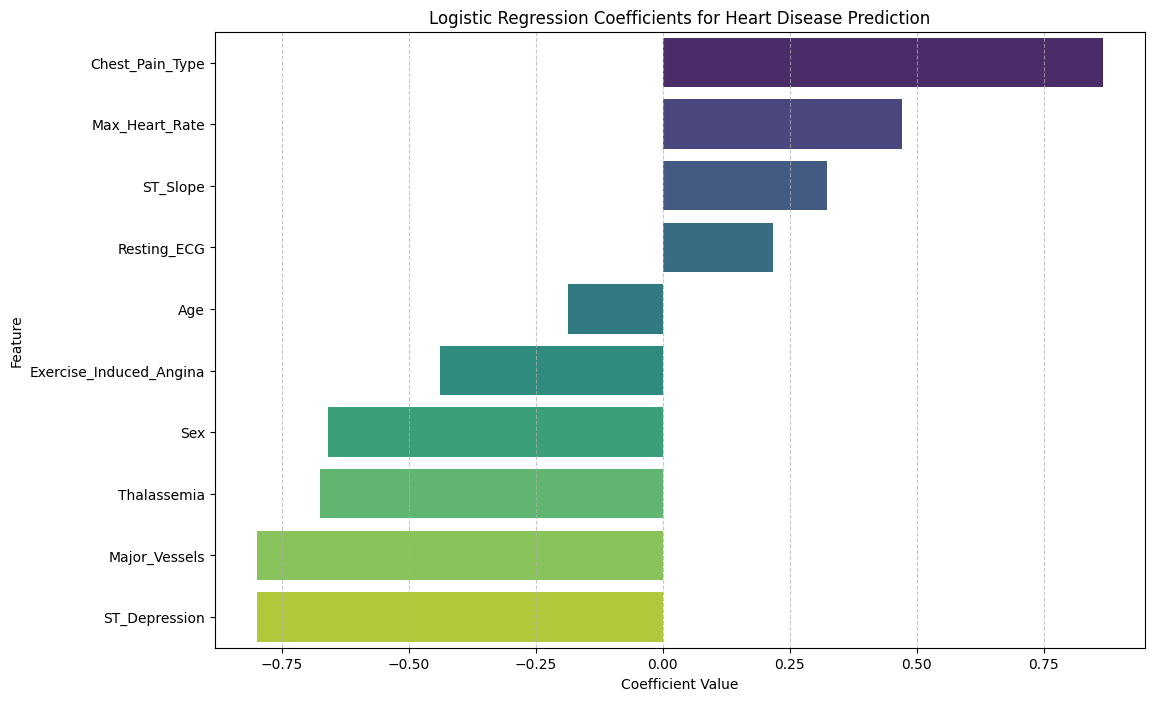

In [ ]:
feature_names = X.columns
coefficients = logistic_reg_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df_sorted, palette='viridis')
plt.title('Logistic Regression Coefficients for Heart Disease Prediction')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Distribution Plots (EDA) for Key Features by Target

Let's visualize the distribution of some key numerical features, separated by the `Heart_Disease` target variable. This can help identify patterns where feature values differ significantly between patients with and without heart disease.

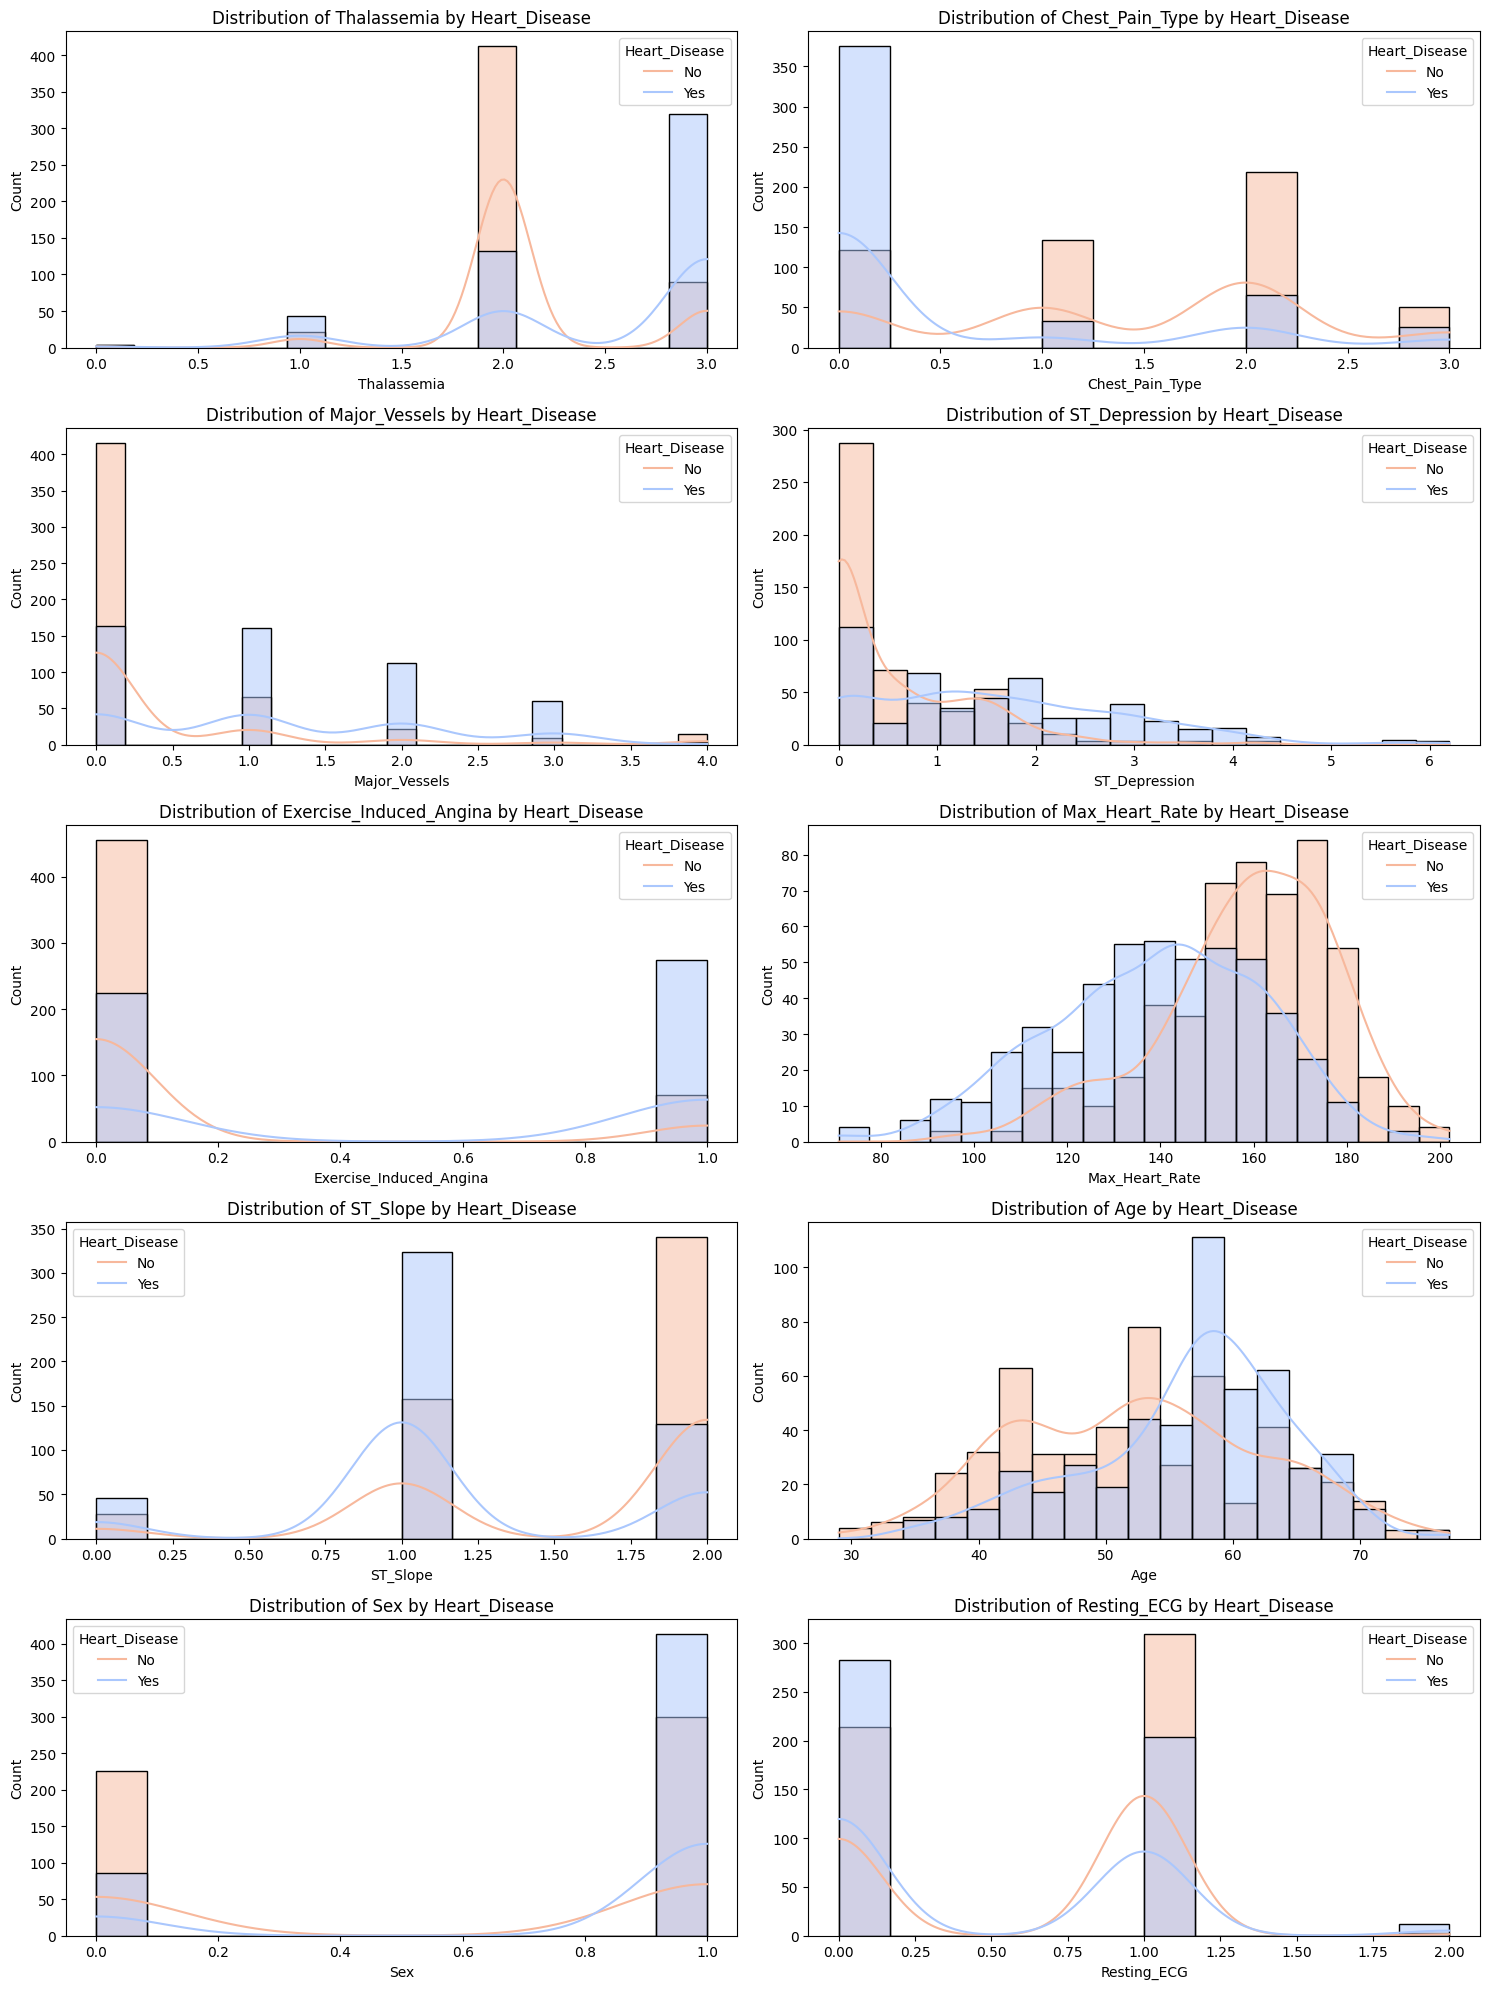

In [ ]:
plt.figure(figsize=(15, 20))
for i, feature in enumerate(selected_features):
    plt.subplot(5, 2, i + 1)
    sns.histplot(data=df, x=feature, hue='Heart_Disease', kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature} by Heart_Disease')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Heart_Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Precision-Recall Curve

The Precision-Recall curve is particularly useful when dealing with imbalanced datasets, as it focuses on the performance of the positive class. High area under the curve represents both high recall and high precision.

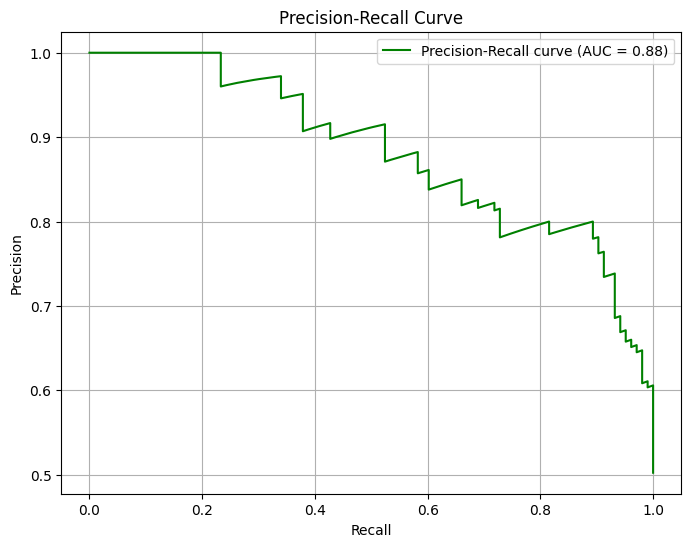

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_lr)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()